# Data Exploration

Reproducing the ML workflow from:
> Xu, J. et al. Anion optimization for bifunctional surface passivation in perovskite solar cells. Nat. Mater. 22, 1507–1514 (2023).

This notebook loads and explores the 267 PH anion dataset with 19 features + binary target.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_dataset

df = load_dataset()
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Dataset shape: (267, 20)
Columns: ['num_C', 'num_F', 'num_O', 'num_P', 'num_S', 'num_B', 'HOMO', 'LUMO', 'min_ESP', 'max_ESP', 'MPI', 'R', 'La', 'Lb', 'Lc', 'MW', 'TPSA', 'C', 'HBA', 'Binding energy']


,num_C,num_F,num_O,num_P,num_S,num_B,HOMO,LUMO,min_ESP,max_ESP,MPI,R,La,Lb,Lc,MW,TPSA,C,HBA,Binding energy
0,1,3,3,0,1,0,-0.09863,0.23484,-74.419685,-122.825939,4.541029,2.78800,5.683,5.687,5.534,149.070000,65.6,145.0,6,1
1,0,0,0,0,0,1,-0.12270,0.20380,-83.830444,-108.757374,4.287288,2.69288,6.161,6.145,6.568,152.600000,0.0,19.1,1,0
2,2,3,2,0,0,0,-0.07304,0.19960,-87.931982,-137.453634,4.789712,2.67976,5.379,5.668,5.117,113.020000,40.1,77.9,5,1
3,1,0,0,0,1,0,-0.02967,0.24341,-98.540922,-126.529241,5.149778,2.54200,3.600,3.600,6.200,58.080000,24.8,31.3,2,0
4,0,6,0,1,0,0,-0.18795,0.24207,-105.898757,-118.425919,4.901822,2.55020,6.220,6.220,6.220,144.964181,0.0,62.7,7,1
5,6,0,0,0,1,0,-0.00686,0.14315,-54.643621,-122.331230,4.092361,3.56782,6.694,8.702,3.600,109.170000,1.0,46.1,1,1
6,2,0,2,0,0,0,-0.02722,0.20263,-54.643621,-153.686081,5.059904,2.46902,5.041,5.313,4.159,59.040000,40.1,25.5,2,1
7,0,0,4,0,0,0,-0.09994,0.22834,-111.118311,-124.501878,5.106741,2.24844,5.109,5.140,5.485,99.450000,74.3,95.8,4,0
8,0,0,0,0,0,0,0.01223,0.28293,-127.286117,-134.860609,5.691619,2.24188,3.100,3.100,5.468,42.021000,3.0,15.5,2,0
9,1,0,0,0,1,0,0.03902,0.21260,-84.325624,-139.552355,5.197809,2.24516,3.930,5.257,4.167,47.100000,1.0,2.0,1,0


In [2]:
# Target distribution
print("=" * 50)
print("Target distribution (Binding energy)")
print("=" * 50)
print(df['Binding energy'].value_counts().sort_index())
print(f"\nHigh Eb (>3 eV): {(df['Binding energy']==1).sum()} ({(df['Binding energy']==1).mean()*100:.1f}%)")
print(f"Low Eb (<=3 eV):  {(df['Binding energy']==0).sum()} ({(df['Binding energy']==0).mean()*100:.1f}%)")

Target distribution (Binding energy)
Binding energy
0     66
1    201
Name: count, dtype: int64

High Eb (>3 eV): 201 (75.3%)
Low Eb (<=3 eV):  66 (24.7%)


In [3]:
# Summary statistics
df.describe().round(4)

,num_C,num_F,num_O,num_P,num_S,num_B,HOMO,LUMO,min_ESP,max_ESP,MPI,R,La,Lb,Lc,MW,TPSA,C,HBA,Binding energy
count,267.0000,267.0000,267.0000,267.0000,267.0000,267.0000,267.0000,267.0000,267.0000,267.0000,267.0000,267.0000,267.0000,267.0000,267.0000,267.0000,267.0000,267.0000,267.0000,267.0000
mean,3.7191,0.2772,2.2659,0.0412,0.3708,0.0412,-0.0470,0.1422,-133.9223,-57.7548,4.3187,3.2895,7.4040,6.3142,4.7186,119.5699,51.6026,93.9655,3.0187,0.7528
std,2.6542,1.0324,1.4485,0.1991,0.5954,0.1991,0.0444,0.0526,15.3154,29.7110,0.6207,0.7070,2.0508,1.3801,1.0375,46.1564,28.5437,69.0694,1.3585,0.4322
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.2004,0.0005,-171.1234,-153.6861,3.1304,1.6293,3.0400,3.1000,2.4010,14.8500,0.0000,0.0000,1.0000,0.0000
25%,2.0000,0.0000,1.0000,0.0000,0.0000,0.0000,-0.0758,0.1053,-143.9203,-68.5373,3.8147,2.7597,5.9820,5.4415,4.1585,87.0850,40.1000,36.5000,2.0000,1.0000
50%,4.0000,0.0000,2.0000,0.0000,0.0000,0.0000,-0.0522,0.1337,-135.5106,-52.4403,4.1736,3.4046,7.6210,6.2810,5.0130,121.2100,57.2000,89.6000,3.0000,1.0000
75%,6.0000,0.0000,3.0000,0.0000,1.0000,0.0000,-0.0284,0.1751,-127.1720,-38.7987,4.7194,3.7285,8.7960,7.0220,5.4975,156.0050,66.5000,131.5000,4.0000,1.0000
max,12.0000,7.0000,7.0000,1.0000,2.0000,1.0000,0.1058,0.2905,-54.6436,2.7719,6.4286,5.4686,13.3080,9.8950,7.2810,297.0900,130.0000,313.0000,9.0000,1.0000


Saved: /home/yhm/desktop/code/anion-paper/figures/corr_matrix_all19.png


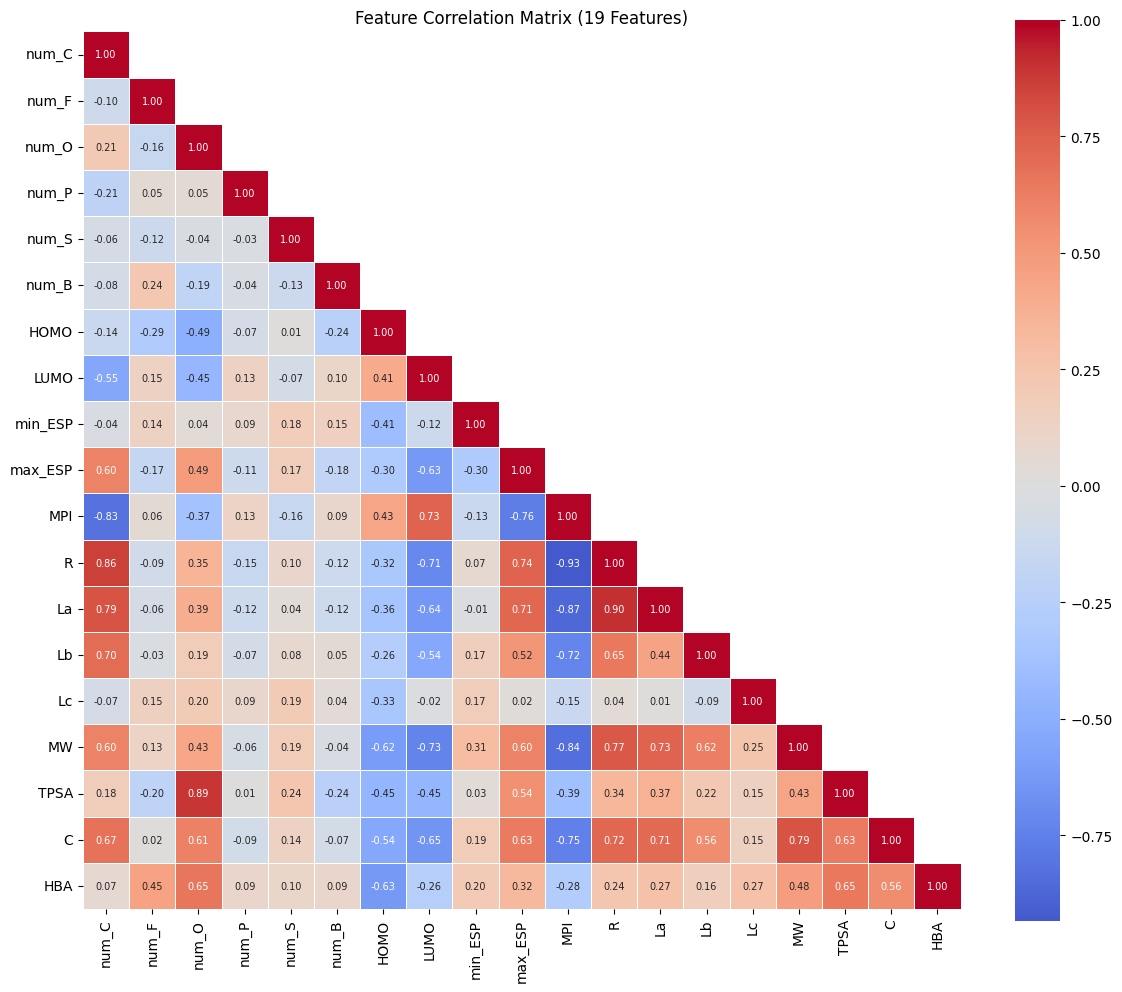


Highly correlated pairs (|r| > 0.85):
  num_C <-> R: r = 0.8595
  num_O <-> TPSA: r = 0.8910
  MPI <-> R: r = -0.9334
  MPI <-> La: r = -0.8686
  R <-> La: r = 0.9037


In [4]:
# Correlation matrix
from src.preprocessing import find_highly_correlated
from src.visualization import plot_correlation_matrix, save_fig

corr = df.drop(columns=['Binding energy']).corr()
fig = plot_correlation_matrix(corr, title="Feature Correlation Matrix (19 Features)")
save_fig(fig, "corr_matrix_all19.png")
plt.show()

# Find highly correlated pairs
high_corr = find_highly_correlated(corr, threshold=0.85)
print("\nHighly correlated pairs (|r| > 0.85):")
for f1, f2, r in high_corr:
    print(f"  {f1} <-> {f2}: r = {r:.4f}")

Saved: /home/yhm/desktop/code/anion-paper/figures/feature_distributions.png


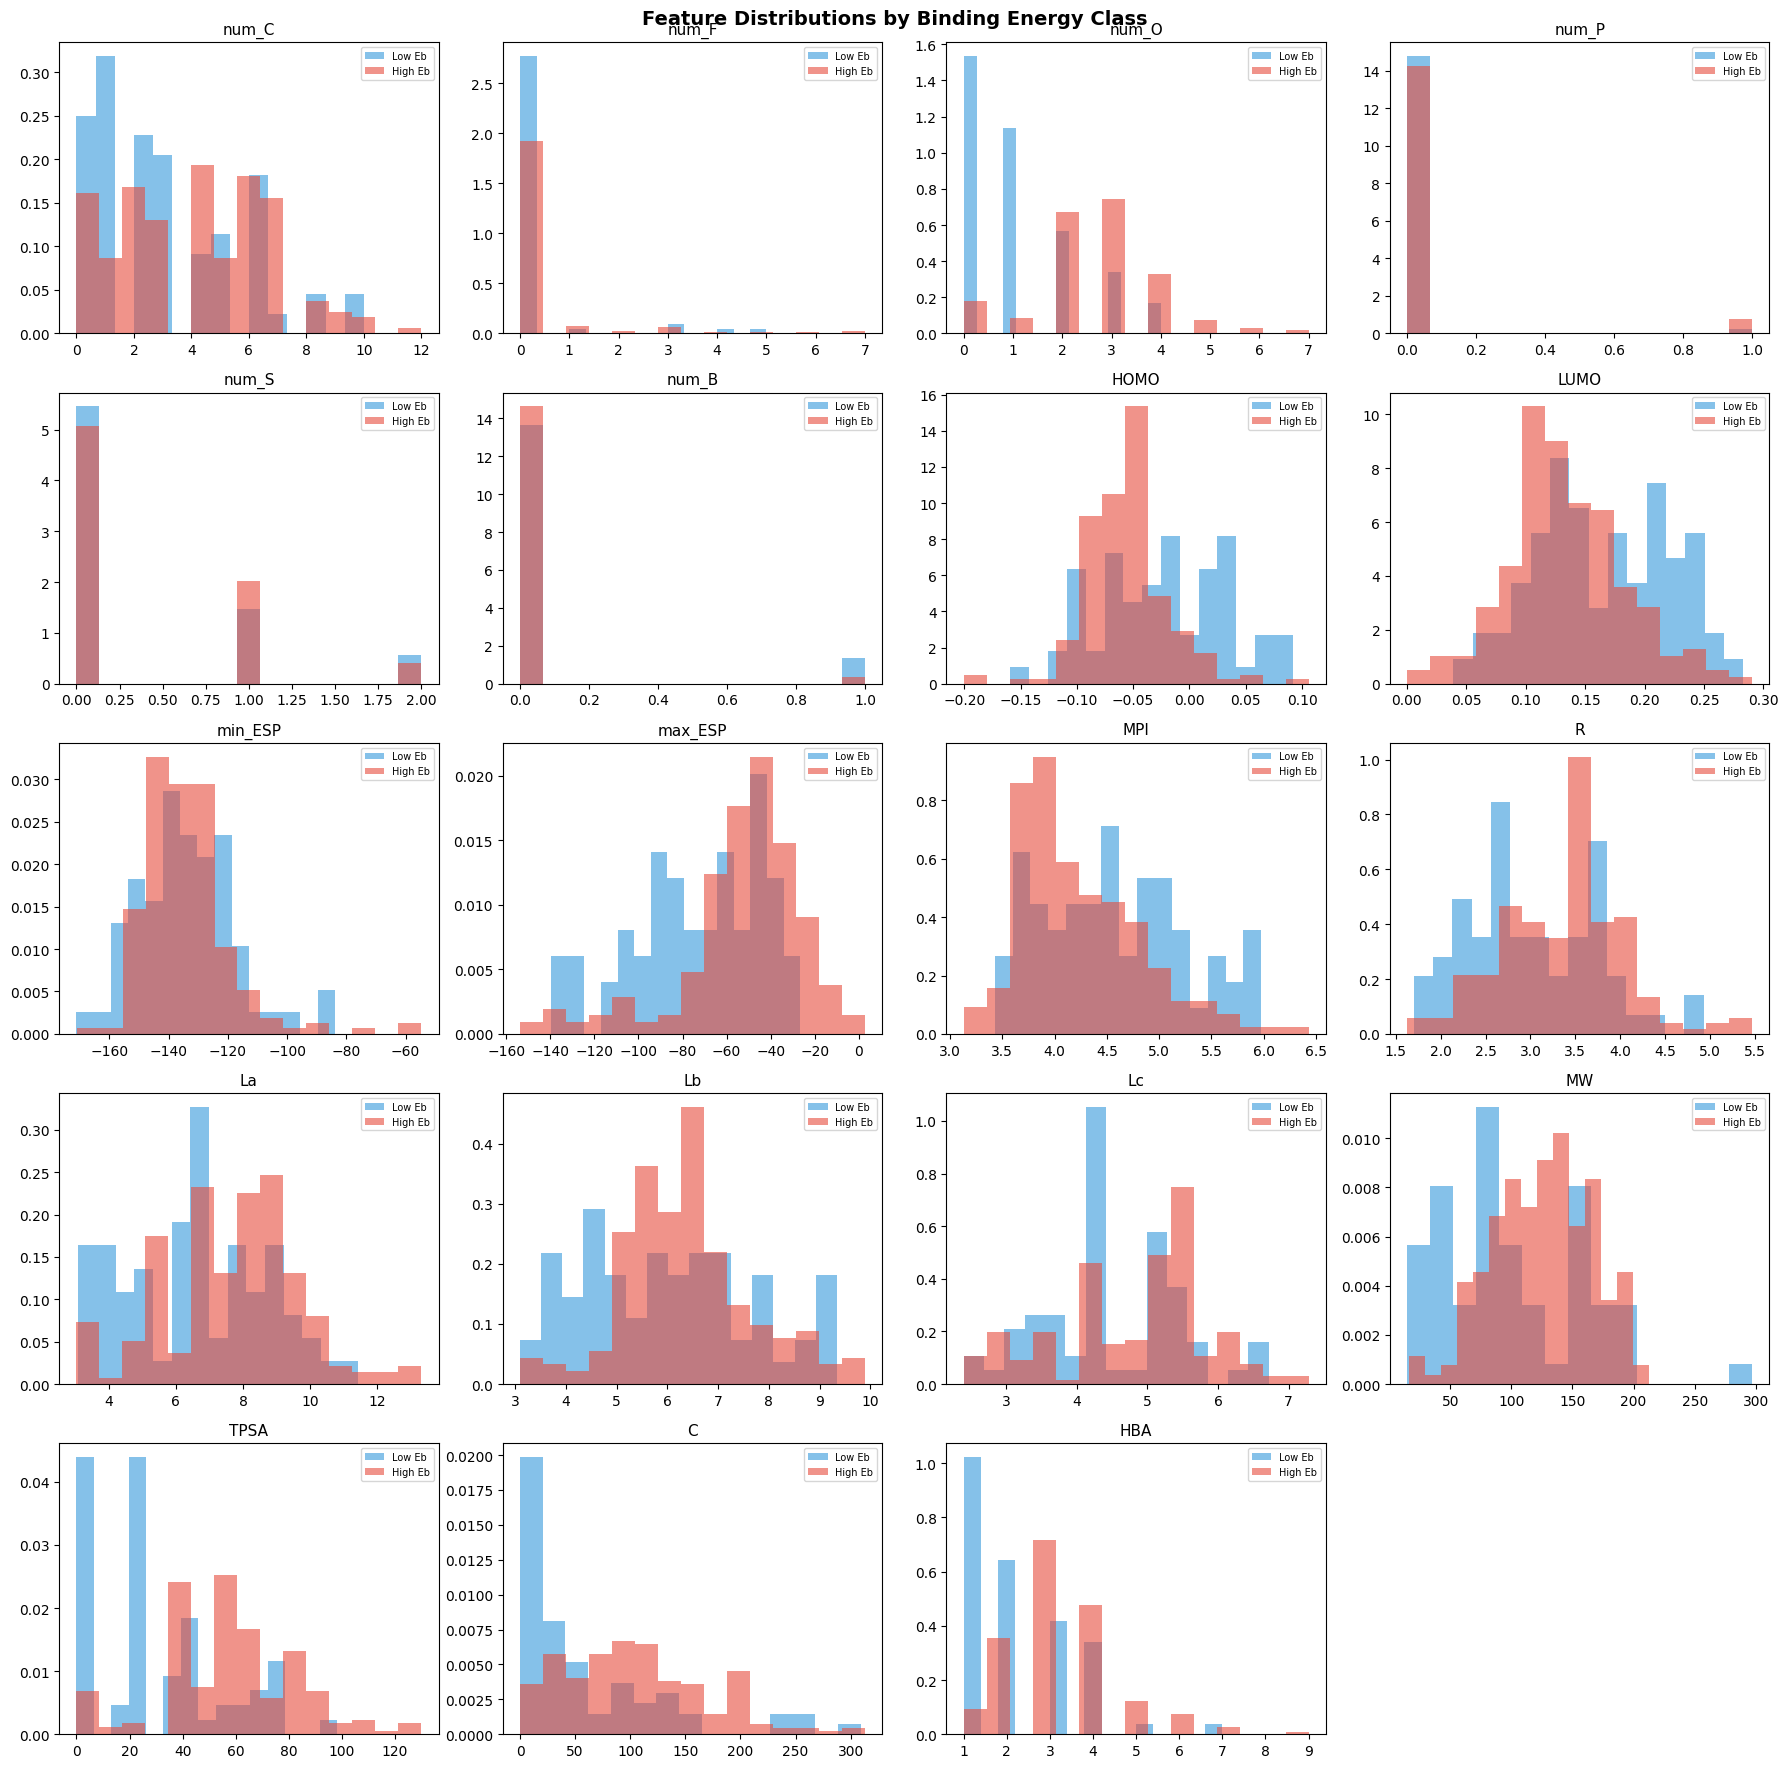

In [5]:
# Feature distributions by class
fig, axes = plt.subplots(5, 4, figsize=(18, 18))
axes = axes.flatten()
features = [c for c in df.columns if c != 'Binding energy']

for i, feat in enumerate(features):
    ax = axes[i]
    for label, color, name in [(0, '#3498db', 'Low Eb'), (1, '#e74c3c', 'High Eb')]:
        subset = df[df['Binding energy'] == label][feat]
        ax.hist(subset, bins=15, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(feat, fontsize=11)
    ax.legend(fontsize=7)

# Hide empty axes
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions by Binding Energy Class", fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig(fig, "feature_distributions.png")
plt.show()

Correlation with Binding Energy:
num_O      0.4777
TPSA       0.4585
HBA        0.3665
max_ESP    0.3106
C          0.2829
MW         0.2330
R          0.2232
La         0.2192
num_C      0.1719
Lc         0.1426
Lb         0.1184
num_P      0.0751
num_S      0.0215
num_F      0.0193
min_ESP   -0.0066
num_B     -0.1433
MPI       -0.2337
LUMO      -0.2573
HOMO      -0.3236
Name: Binding energy, dtype: float64


Saved: /home/yhm/desktop/code/anion-paper/figures/feature_target_corr.png


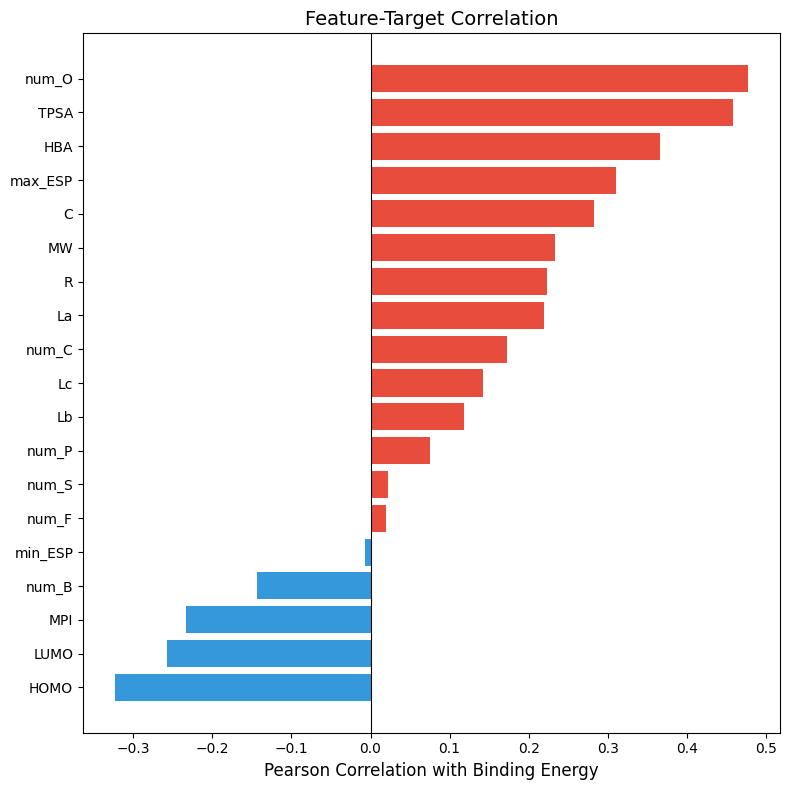

In [6]:
# Correlation with target
corr_target = df.corr()['Binding energy'].drop('Binding energy').sort_values(ascending=False)
print("Correlation with Binding Energy:")
print(corr_target.round(4))

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_target.values]
ax.barh(range(len(corr_target)), corr_target.values, color=colors)
ax.set_yticks(range(len(corr_target)))
ax.set_yticklabels(corr_target.index)
ax.set_xlabel("Pearson Correlation with Binding Energy", fontsize=12)
ax.set_title("Feature-Target Correlation", fontsize=14)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.invert_yaxis()
plt.tight_layout()
save_fig(fig, "feature_target_corr.png")
plt.show()